In [ ]:
"""
Self-Consistency Analysis Notebook
===================================
Reproducing and extending Wang et al. (2023) on modern SLMs
Run each section as a separate Jupyter cell.
"""

In [3]:
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
 
# --- Load Mistral-7B ---
with open(r"E:\LLM\CCE_IISc_Large_Language_Models\Final_Project\Self_Consistency_Data\greedy_mistral_0_1318.json") as f:
    greedy_mistral = json.load(f)
with open(r"E:\LLM\CCE_IISc_Large_Language_Models\Final_Project\Self_Consistency_Data\sc_mistral_0_1318.json") as f:
    sc_mistral = json.load(f)
 
# --- Load Gemma-9B ---
with open(r"E:\LLM\CCE_IISc_Large_Language_Models\Final_Project\Self_Consistency_Data\greedy_gemma_9_billion_0_1318.json") as f:
    greedy_gemma9 = json.load(f)
with open(r"E:\LLM\CCE_IISc_Large_Language_Models\Final_Project\Self_Consistency_Data\sc_gemma_9_billion_0_1318.json") as f:
    sc_gemma9 = json.load(f)
 
# --- Load Gemma-2B ---
with open(r"E:\LLM\CCE_IISc_Large_Language_Models\Final_Project\Self_Consistency_Data\greedy_gemma_2billion_0_1318.json") as f:
    greedy_gemma2 = json.load(f)
with open(r"E:\LLM\CCE_IISc_Large_Language_Models\Final_Project\Self_Consistency_Data\sc_gemma_2_billion_0_1318.json") as f:
    sc_gemma2 = json.load(f)
 
# --- Load Phi-3-mini ---
# Greedy: from Excel
phi_greedy_df = pd.read_excel(r"E:\LLM\CCE_IISc_Large_Language_Models\Final_Project\Self_Consistency_Data\results_0_1318_greedy.xlsx")
greedy_phi = {}
for _, row in phi_greedy_df.iterrows():
    idx = str(int(row["Unnamed: 0"]))
    greedy_phi[idx] = [row[0], row[1], row[2], row[3], [row[1]]]
 
# SC: batch1 has all 1319 results but NO raw 40 samples
# batch2 has questions 277-1318 WITH raw 40 samples
phi_sc_full_df = pd.read_excel(r"E:\LLM\CCE_IISc_Large_Language_Models\Final_Project\Self_Consistency_Data\results_0_276_self_consistency.xlsx")
phi_sc_batch2_df = pd.read_excel(r"E:\LLM\CCE_IISc_Large_Language_Models\Final_Project\Self_Consistency_Data\results_277_1318_self_consistency.xlsx")
 
# Build sc_phi: full results for accuracy, raw samples only for 277-1318
sc_phi = {}
for _, row in phi_sc_full_df.iterrows():
    idx = str(int(row["Unnamed: 0"]))
    sc_phi[idx] = [row[0], row[1], row[2], row[3], None]  # no raw samples
 
# Overlay batch2 raw samples
for _, row in phi_sc_batch2_df.iterrows():
    idx = str(int(row["Unnamed: 0"]))
    raw_samples = ast.literal_eval(str(row[4]))
    sc_phi[idx] = [row[0], row[1], row[2], row[3], raw_samples]
 
print("Data loaded successfully!")
print(f"Phi-3-mini:  {len(greedy_phi)} greedy, {len(sc_phi)} SC")
print(f"Mistral-7B:  {len(greedy_mistral)} greedy, {len(sc_mistral)} SC")
print(f"Gemma-9B:    {len(greedy_gemma9)} greedy, {len(sc_gemma9)} SC")
print(f"Gemma-2B:    {len(greedy_gemma2)} greedy, {len(sc_gemma2)} SC")

Data loaded successfully!
Phi-3-mini:  1319 greedy, 1319 SC
Mistral-7B:  1319 greedy, 1319 SC
Gemma-9B:    1319 greedy, 1319 SC
Gemma-2B:    1319 greedy, 1319 SC


# ============================================================
# CELL 2: Helper Functions
# ============================================================

In [4]:
def compute_accuracy(data_dict):
    """Compute accuracy from a results dict."""
    correct = sum(1 for v in data_dict.values() if v[3])
    return correct / len(data_dict) * 100
 
def majority_vote(answers, m):
    """Take majority vote over first m answers."""
    subset = [a for a in answers[:m] if a is not None]
    if not subset:
        return None
    return Counter(subset).most_common(1)[0][0]
 
def is_correct(pred, gold):
    """Check if prediction matches gold."""
    if pred is None:
        return False
    return abs(float(pred) - float(gold)) < 1e-6
 
def compute_accuracy_at_m(sc_data, m_values):
    """Compute SC accuracy at different numbers of sampled paths."""
    accuracies = []
    for m in m_values:
        correct = 0
        total = 0
        for key, val in sc_data.items():
            raw_samples = val[4]
            if raw_samples is None:
                continue  # skip questions without raw samples
            gold = val[2]
            pred = majority_vote(raw_samples, m)
            if is_correct(pred, gold):
                correct += 1
            total += 1
        accuracies.append(correct / total * 100 if total > 0 else 0)
    return accuracies

#### ============================================================
### CELL 3: Compute Summary Table (Table 2)
#### ============================================================

In [5]:
models = {
    "Gemma-2B (2.6B)":   (greedy_gemma2, sc_gemma2),
    "Phi-3-mini (3.8B)": (greedy_phi, sc_phi),
    "Mistral-7B (7.2B)": (greedy_mistral, sc_mistral),
    "Gemma-9B (9B)":     (greedy_gemma9, sc_gemma9),
}
 
print(f"{'Model':<22} {'Params':>7} {'Greedy':>8} {'SC@40':>8} {'Gain':>8} {'Headroom':>10}")
print("-" * 70)
 
summary_data = []
for name, (greedy, sc) in models.items():
    g_acc = compute_accuracy(greedy)
    s_acc = compute_accuracy(sc)
    gain = s_acc - g_acc
    headroom = 100 - g_acc
    gain_str = f"+{gain:.1f}%"
    print(f"{name:<22} {'':>7} {g_acc:>7.1f}% {s_acc:>7.1f}% {gain_str:>8} {headroom:>9.1f}%")
    summary_data.append({
        "model": name,
        "greedy": g_acc,
        "sc": s_acc,
        "gain": gain,
        "headroom": headroom,
    })
 

Model                   Params   Greedy    SC@40     Gain   Headroom
----------------------------------------------------------------------
Gemma-2B (2.6B)                   50.2%    59.5%    +9.3%      49.8%
Phi-3-mini (3.8B)                 84.8%    91.3%    +6.4%      15.2%
Mistral-7B (7.2B)                 54.0%    72.9%   +19.0%      46.0%
Gemma-9B (9B)                     86.1%    89.4%    +3.3%      13.9%


##### ============================================================
##### CELL 4: Plot 1 — Summary Bar Chart (Your Table 2 visualized)
##### ============================================================

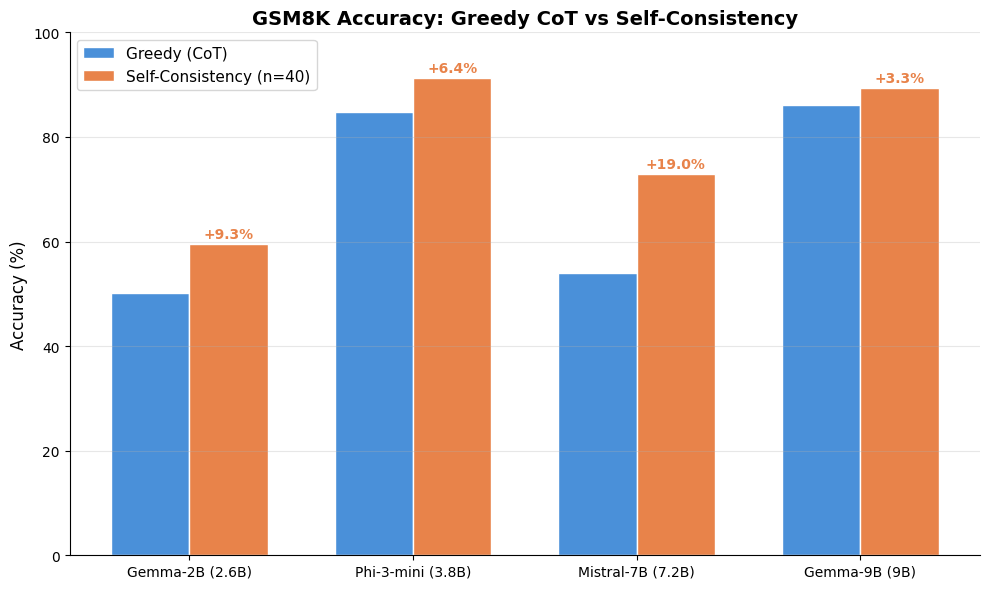

Saved: plot1_summary_bar_chart.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
 
model_names = [d["model"] for d in summary_data]
greedy_accs = [d["greedy"] for d in summary_data]
sc_accs = [d["sc"] for d in summary_data]
 
x = np.arange(len(model_names))
width = 0.35
 
bars1 = ax.bar(x - width/2, greedy_accs, width, label="Greedy (CoT)", color="#4A90D9", edgecolor="white")
bars2 = ax.bar(x + width/2, sc_accs, width, label="Self-Consistency (n=40)", color="#E8834A", edgecolor="white")
 
# Add gain labels on top of SC bars
for i, d in enumerate(summary_data):
    ax.annotate(f'+{d["gain"]:.1f}%',
                xy=(x[i] + width/2, d["sc"] + 0.5),
                ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='#E8834A')
 
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("GSM8K Accuracy: Greedy CoT vs Self-Consistency", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
plt.tight_layout()
plt.savefig("plot1_summary_bar_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot1_summary_bar_chart.png")

#### ============================================================
#### CELL 5: Plot 2 — Accuracy vs Number of Sampled Paths (Your Figure 2)
#### ============================================================

Gemma-2B (2.6B): ['46.6', '54.2', '57.3', '58.7', '59.0', '59.1', '59.5']
Phi-3-mini (3.8B): ['83.1', '88.8', '90.0', '90.4', '90.7', '90.6', '90.8']
Mistral-7B (7.2B): ['51.4', '64.4', '69.0', '69.9', '71.6', '72.3', '72.9']
Gemma-9B (9B): ['85.9', '88.6', '88.6', '88.7', '88.6', '89.3', '89.4']


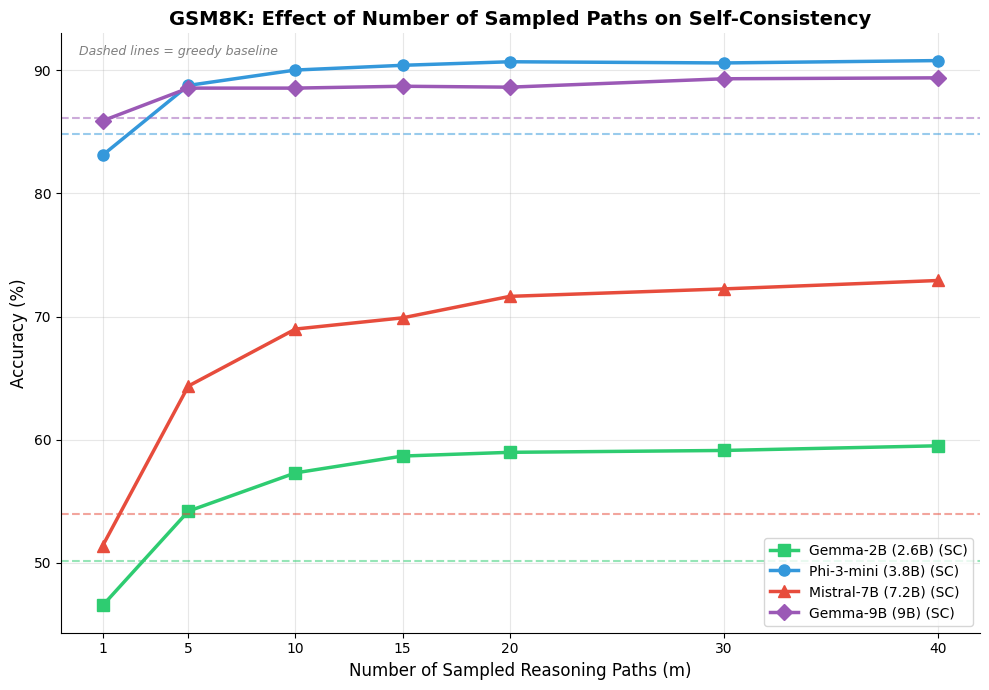

Saved: plot2_accuracy_vs_paths.png


In [7]:
m_values = [1, 5, 10, 15, 20, 30, 40]
 
# Compute ablation curves for each model
# Note: Phi only has raw samples for questions 277-1318
ablation_results = {}
sc_datasets = {
    "Gemma-2B (2.6B)":   sc_gemma2,
    "Phi-3-mini (3.8B)": sc_phi,       # will skip questions 0-276 (no raw samples)
    "Mistral-7B (7.2B)": sc_mistral,
    "Gemma-9B (9B)":     sc_gemma9,
}
 
for name, sc_data in sc_datasets.items():
    accs = compute_accuracy_at_m(sc_data, m_values)
    ablation_results[name] = accs
    print(f"{name}: {[f'{a:.1f}' for a in accs]}")
 
# Also compute greedy baselines for reference lines
greedy_baselines = {
    "Gemma-2B (2.6B)":   compute_accuracy(greedy_gemma2),
    "Phi-3-mini (3.8B)": compute_accuracy(greedy_phi),
    "Mistral-7B (7.2B)": compute_accuracy(greedy_mistral),
    "Gemma-9B (9B)":     compute_accuracy(greedy_gemma9),
}
 
fig, ax = plt.subplots(figsize=(10, 7))
 
colors = {
    "Gemma-2B (2.6B)":   "#2ECC71",
    "Phi-3-mini (3.8B)": "#3498DB",
    "Mistral-7B (7.2B)": "#E74C3C",
    "Gemma-9B (9B)":     "#9B59B6",
}
 
markers = {
    "Gemma-2B (2.6B)":   "s",
    "Phi-3-mini (3.8B)": "o",
    "Mistral-7B (7.2B)": "^",
    "Gemma-9B (9B)":     "D",
}
 
for name, accs in ablation_results.items():
    ax.plot(m_values, accs,
            marker=markers[name], markersize=8,
            linewidth=2.5, label=f"{name} (SC)",
            color=colors[name])
    # Greedy baseline as dashed horizontal line
    ax.axhline(y=greedy_baselines[name],
               color=colors[name], linestyle='--', alpha=0.5, linewidth=1.5)
 
ax.set_xlabel("Number of Sampled Reasoning Paths (m)", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("GSM8K: Effect of Number of Sampled Paths on Self-Consistency",
             fontsize=14, fontweight='bold')
ax.set_xticks(m_values)
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
# Add annotation explaining dashed lines
ax.text(0.02, 0.98, "Dashed lines = greedy baseline",
        transform=ax.transAxes, fontsize=9, va='top',
        style='italic', color='gray')
 
plt.tight_layout()
plt.savefig("plot2_accuracy_vs_paths.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot2_accuracy_vs_paths.png")

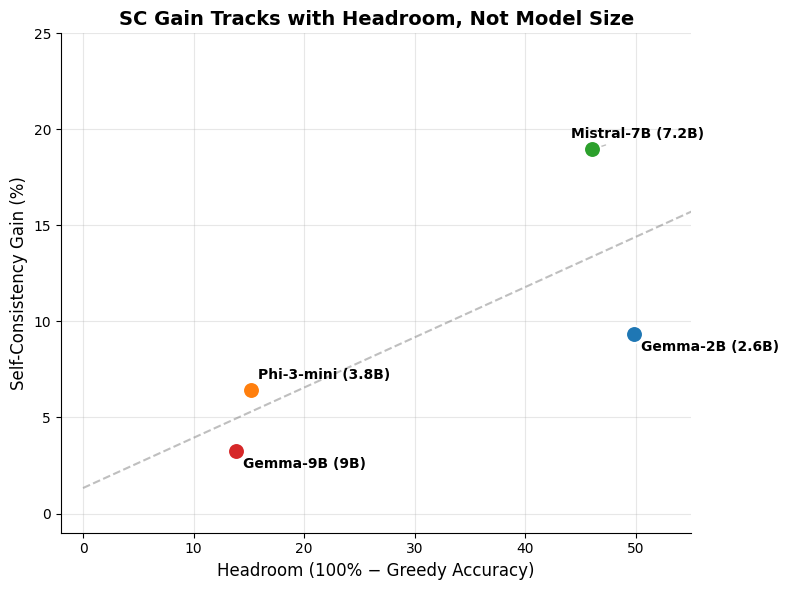

Saved: plot3_headroom_vs_gain.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
 
for d in summary_data:
    ax.scatter(d["headroom"], d["gain"],
               s=150, zorder=5, edgecolors='white', linewidth=1.5)
    # Label each point with model name
    # Offset labels to avoid overlap
    offsets = {
        "Gemma-2B (2.6B)":   (5, -12),
        "Phi-3-mini (3.8B)": (5, 8),
        "Mistral-7B (7.2B)": (-15, 8),
        "Gemma-9B (9B)":     (5, -12),
    }
    ox, oy = offsets.get(d["model"], (5, 5))
    ax.annotate(d["model"],
                xy=(d["headroom"], d["gain"]),
                xytext=(ox, oy),
                textcoords='offset points',
                fontsize=10, fontweight='bold',
                arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5) if abs(ox) > 10 else None)
 
# Fit a trend line
headrooms = [d["headroom"] for d in summary_data]
gains = [d["gain"] for d in summary_data]
z = np.polyfit(headrooms, gains, 1)
p = np.poly1d(z)
x_line = np.linspace(0, 55, 100)
ax.plot(x_line, p(x_line), '--', color='gray', alpha=0.5, linewidth=1.5, label=f'Trend line')
 
ax.set_xlabel("Headroom (100% − Greedy Accuracy)", fontsize=12)
ax.set_ylabel("Self-Consistency Gain (%)", fontsize=12)
ax.set_title("SC Gain Tracks with Headroom, Not Model Size",
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(-2, 55)
ax.set_ylim(-1, 25)
 
plt.tight_layout()
plt.savefig("plot3_headroom_vs_gain.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot3_headroom_vs_gain.png")

Gemma-2B (2.6B):  Both right=608, SC fixed=177, SC broke=54, Both wrong=480
Phi-3-mini (3.8B):  Both right=1107, SC fixed=97, SC broke=12, Both wrong=103
Mistral-7B (7.2B):  Both right=675, SC fixed=287, SC broke=37, Both wrong=320
Gemma-9B (9B):  Both right=1122, SC fixed=57, SC broke=14, Both wrong=126


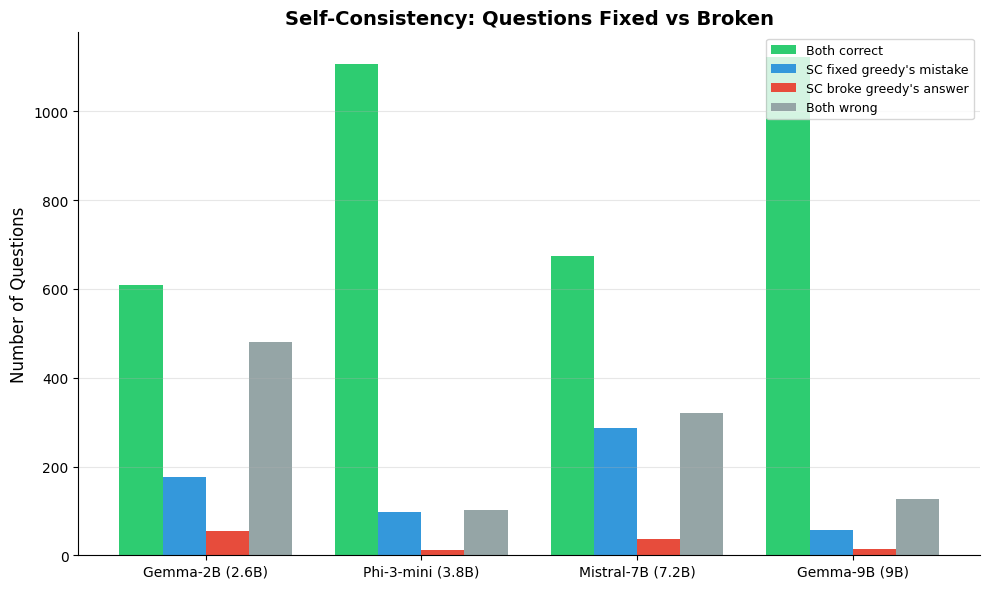

Saved: plot4_breakdown.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
 
breakdown_data = []
for name, (greedy, sc) in models.items():
    both_right = 0
    sc_fixed = 0
    sc_broke = 0
    both_wrong = 0
 
    for key in greedy:
        g_correct = greedy[key][3]
        s_correct = sc[key][3]
 
        if g_correct and s_correct:
            both_right += 1
        elif not g_correct and s_correct:
            sc_fixed += 1
        elif g_correct and not s_correct:
            sc_broke += 1
        else:
            both_wrong += 1
 
    total = len(greedy)
    breakdown_data.append({
        "model": name,
        "both_right": both_right,
        "sc_fixed": sc_fixed,
        "sc_broke": sc_broke,
        "both_wrong": both_wrong,
    })
    print(f"{name}:  Both right={both_right}, SC fixed={sc_fixed}, SC broke={sc_broke}, Both wrong={both_wrong}")
 
model_names_short = [d["model"] for d in breakdown_data]
x = np.arange(len(model_names_short))
width = 0.2
 
ax.bar(x - 1.5*width, [d["both_right"] for d in breakdown_data], width,
       label="Both correct", color="#2ECC71")
ax.bar(x - 0.5*width, [d["sc_fixed"] for d in breakdown_data], width,
       label="SC fixed greedy's mistake", color="#3498DB")
ax.bar(x + 0.5*width, [d["sc_broke"] for d in breakdown_data], width,
       label="SC broke greedy's answer", color="#E74C3C")
ax.bar(x + 1.5*width, [d["both_wrong"] for d in breakdown_data], width,
       label="Both wrong", color="#95A5A6")
 
ax.set_ylabel("Number of Questions", fontsize=12)
ax.set_title("Self-Consistency: Questions Fixed vs Broken", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names_short, fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
plt.tight_layout()
plt.savefig("plot4_breakdown.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot4_breakdown.png")
 

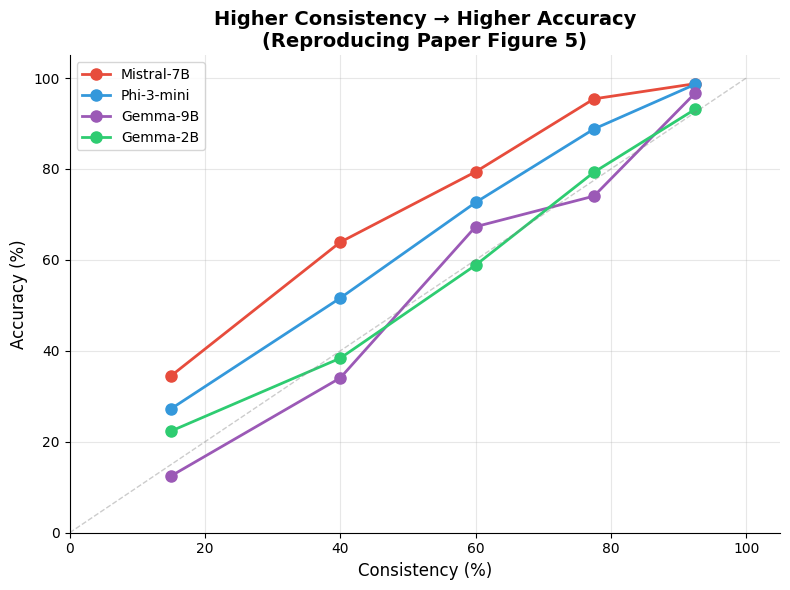

Saved: plot5_consistency_vs_accuracy.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
 
for name, sc_data, color in [
    ("Mistral-7B", sc_mistral, "#E74C3C"),
    ("Phi-3-mini", sc_phi, "#3498DB"),
    ("Gemma-9B", sc_gemma9, "#9B59B6"),
    ("Gemma-2B", sc_gemma2, "#2ECC71"),
]:
    consistencies = []
    corrects = []
 
    for key, val in sc_data.items():
        raw = val[4]
        if raw is None:
            continue
        gold = val[2]
 
        valid = [a for a in raw if a is not None]
        if not valid:
            continue
 
        majority = Counter(valid).most_common(1)[0][0]
        consistency = sum(1 for a in valid if a == majority) / len(valid) * 100
        correct = is_correct(majority, gold)
 
        consistencies.append(consistency)
        corrects.append(correct)
 
    # Bin by consistency
    bins = [(0, 30), (30, 50), (50, 70), (70, 85), (85, 100)]
    bin_centers = []
    bin_accs = []
 
    for low, high in bins:
        mask = [(low <= c < high) if high < 100 else (low <= c <= high)
                for c in consistencies]
        if sum(mask) < 5:
            continue
        bin_correct = sum(c for c, m in zip(corrects, mask) if m)
        bin_total = sum(mask)
        bin_centers.append((low + high) / 2)
        bin_accs.append(bin_correct / bin_total * 100)
 
    ax.plot(bin_centers, bin_accs, marker='o', linewidth=2, markersize=8,
            label=name, color=color)
 
ax.plot([0, 100], [0, 100], '--', color='gray', alpha=0.4, linewidth=1)
ax.set_xlabel("Consistency (%)", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Higher Consistency → Higher Accuracy\n(Reproducing Paper Figure 5)",
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, 105)
ax.set_ylim(0, 105)
 
plt.tight_layout()
plt.savefig("plot5_consistency_vs_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot5_consistency_vs_accuracy.png")

In [11]:
print("\n" + "=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)
print(f"\n{'Model':<22} {'Params':>7} {'Greedy':>8} {'SC@40':>8} {'Gain':>8} {'Headroom':>10}")
print("-" * 70)
for d in summary_data:
    gain_str = f"+{d['gain']:.1f}%"
    print(f"{d['model']:<22} {'':>7} {d['greedy']:>7.1f}% {d['sc']:>7.1f}% {gain_str:>8} {d['headroom']:>9.1f}%")
 
print(f"\n{'=' * 70}")
print("KEY FINDINGS")
print("=" * 70)
print("""
1. Self-consistency improves accuracy across ALL tested models.
   Gains range from +3.3% (Gemma-9B) to +19.0% (Mistral-7B).
 
2. SC gain tracks with HEADROOM, not model size.
   - Largest model (Gemma-9B, 9B params): smallest gain (+3.3%)
   - Smallest model (Gemma-2B, 2.6B params): modest gain (+9.3%)
   - Medium model (Mistral-7B, 7.2B params): largest gain (+19.0%)
 
3. SC gain requires BOTH headroom AND sufficient base capability.
   - Gemma-2B has high headroom (49.8%) but modest gain (+9.3%)
     because it's often consistently wrong across all paths.
   - Mistral-7B has similar headroom (46.0%) but much larger gain (+19.0%)
     because it's capable enough to sometimes produce correct paths.
 
4. The paper's finding that 'SC gains increase with scale' was a special
   case: within one model family, larger models are always better, so
   scale and capability are confounded. Across model families, SC gain
   depends on base capability and headroom, not parameter count.
 
5. Most SC gains are captured by m=10-20 paths (see ablation plot),
   consistent with the paper's Figure 2.
""")
 
print("Plots saved:")
print("  - plot1_summary_bar_chart.png")
print("  - plot2_accuracy_vs_paths.png")
print("  - plot3_headroom_vs_gain.png")
print("  - plot4_breakdown.png")
print("  - plot5_consistency_vs_accuracy.png")


FINAL RESULTS SUMMARY

Model                   Params   Greedy    SC@40     Gain   Headroom
----------------------------------------------------------------------
Gemma-2B (2.6B)                   50.2%    59.5%    +9.3%      49.8%
Phi-3-mini (3.8B)                 84.8%    91.3%    +6.4%      15.2%
Mistral-7B (7.2B)                 54.0%    72.9%   +19.0%      46.0%
Gemma-9B (9B)                     86.1%    89.4%    +3.3%      13.9%

KEY FINDINGS

1. Self-consistency improves accuracy across ALL tested models.
   Gains range from +3.3% (Gemma-9B) to +19.0% (Mistral-7B).
 
2. SC gain tracks with HEADROOM, not model size.
   - Largest model (Gemma-9B, 9B params): smallest gain (+3.3%)
   - Smallest model (Gemma-2B, 2.6B params): modest gain (+9.3%)
   - Medium model (Mistral-7B, 7.2B params): largest gain (+19.0%)
 
3. SC gain requires BOTH headroom AND sufficient base capability.
   - Gemma-2B has high headroom (49.8%) but modest gain (+9.3%)
     because it's often consistently wron